In [3]:
from loopr.models.unet import load_unet
from torch.utils.data import DataLoader
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
import torch
from loopr.losses.weighted_focal import WeightedFocalDiceLoss
from loopr.training.train_unet import fit
from loopr.config.training_unet import TrainingUnetConfig
from loopr.data.semantic_segmentation import get_train_transforms, get_valid_transforms,  SemanticSegmentationDataset, collate_fn
from loopr.eda.class_visualization import number_of_files_per_class

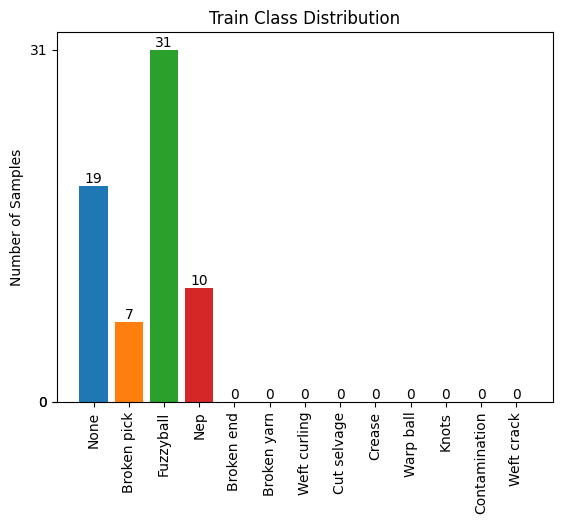

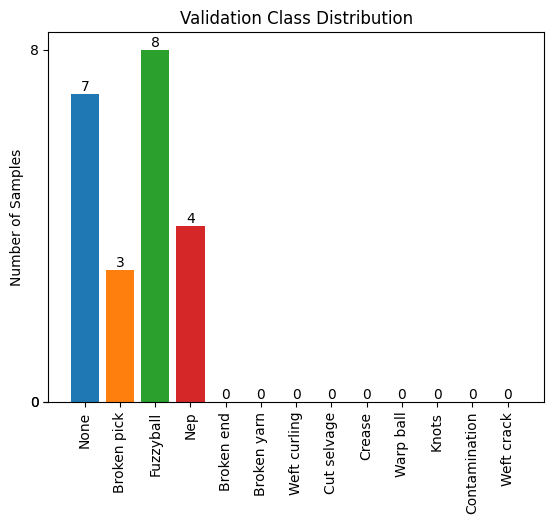

In [4]:
# Load Model
unet_model = load_unet(TrainingUnetConfig.pretrained_path,gpu=True)
unet_model.train()
# Load Data
train_ds = SemanticSegmentationDataset(
    transforms=get_train_transforms(), 
    training=True,
    censor_class = {0: 20}
)
valid_ds = SemanticSegmentationDataset(
    transforms=get_valid_transforms(), 
    training=False,
    censor_class = {0: 8}
)
number_of_files_per_class(train_ds, valid_ds)

In [5]:

train_loader = DataLoader(train_ds, batch_size=TrainingUnetConfig.batch_size,
                          shuffle=True, num_workers=TrainingUnetConfig.num_workers,
                          collate_fn=collate_fn)

valid_loader = DataLoader(valid_ds, batch_size=TrainingUnetConfig.batch_size,
                          shuffle=False, num_workers=TrainingUnetConfig.num_workers,
                          collate_fn=collate_fn)
# Weight loss for imbalanced data
from collections import Counter
class_counts = Counter(train_ds.classes)
total_count = sum(list(class_counts.values()))
class_weights=[1,1,1,1]
criterion = WeightedFocalDiceLoss(class_weights=class_weights)
optimizer = Adam(unet_model.parameters(), lr=TrainingUnetConfig.lr, weight_decay=TrainingUnetConfig.weight_decay)
scheduler = ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2)


# Eğitimi başlat ve history yakala
history = fit(unet_model.cuda(), train_loader, valid_loader, optimizer, scheduler, criterion, TrainingUnetConfig.device,
              num_epochs=TrainingUnetConfig.epochs, early_stopping_patience=TrainingUnetConfig.early_stopping_patience, save_path=TrainingUnetConfig.pretrained_path)



Epoch 1/10


Train Loss: 0.5747, Dice: 0.5858
Valid Loss: 1.6372, Dice: 0.3200
✅ Best model saved at epoch 1 (dice=0.3200)

Epoch 2/10


Train Loss: 0.4690, Dice: 0.7052
Valid Loss: 0.5843, Dice: 0.5909
✅ Best model saved at epoch 2 (dice=0.5909)

Epoch 3/10


Train Loss: 0.3971, Dice: 0.6940
Valid Loss: 0.4424, Dice: 0.6705
✅ Best model saved at epoch 3 (dice=0.6705)

Epoch 4/10


Train Loss: 0.3600, Dice: 0.7239
Valid Loss: 0.7853, Dice: 0.6818
✅ Best model saved at epoch 4 (dice=0.6818)

Epoch 5/10


...

Train Loss: 0.3195, Dice: 0.7242
Valid Loss: 0.4117, Dice: 0.7164
✅ Best model saved at epoch 6 (dice=0.7164)

Epoch 7/10


Train Loss: 0.3135, Dice: 0.7276
Valid Loss: 0.3400, Dice: 0.7188
✅ Best model saved at epoch 7 (dice=0.7188)

Epoch 8/10


Train Loss: 0.3022, Dice: 0.7551
Valid Loss: 0.2931, Dice: 0.7605
✅ Best model saved at epoch 8 (dice=0.7605)

Epoch 9/10


Train Loss: 0.2937, Dice: 0.8023
Valid Loss: 0.2850, Dice: 0.8549
✅ Best model saved at epoch 9 (dice=0.8549)

Epoch 10/10


Train Loss: 0.2867, Dice: 0.8837
Valid Loss: 0.2830, Dice: 0.9084
✅ Best model saved at epoch 10 (dice=0.9084)
Training finished. Best Dice = 0.9084


In [6]:
history

{'train': [{'loss': 0.5746708788088898,
   'dice': 0.5858209044186037,
   'lr': 0.0003},
  {'loss': 0.4690412790028017, 'dice': 0.7052238814866365, 'lr': 0.0003},
  {'loss': 0.3971449470342095, 'dice': 0.6940298507462687, 'lr': 0.0003},
  {'loss': 0.35999766659380783, 'dice': 0.7238805970149254, 'lr': 0.0003},
  {'loss': 0.3355597813627613, 'dice': 0.7238845825195312, 'lr': 0.0003},
  {'loss': 0.3194734783314947, 'dice': 0.7241633552223888, 'lr': 0.0003},
  {'loss': 0.3134651362006344, 'dice': 0.7276120799690929, 'lr': 0.0003},
  {'loss': 0.3021851791374719, 'dice': 0.7551153186541885, 'lr': 0.0003},
  {'loss': 0.2937236059067854, 'dice': 0.8022552266049741, 'lr': 0.0003},
  {'loss': 0.28668523991285866, 'dice': 0.8836989669657466, 'lr': 0.0003}],
 'valid': [{'loss': 1.6372264948758213,
   'dice': 0.32004127177325165,
   'per_class_dice': [0.006975097853379945,
    0.3333333339596436,
    1.0068193992638734e-10,
    1.9989949163560597e-10]},
  {'loss': 0.5843363539739088,
   'dice': 0.

In [ ]:
unet_model = load_unet(TrainingUnetConfig.pretrained_path,gpu=True)
unet_model.eval()
import matplotlib.pyplot as plt
import numpy as np
for i,(img, mask, meta) in enumerate(train_ds):
    # if i==5:
    #     break
    # Overlay
    overlay = np.array(img)
    # mask = np.repeat(np.array(mask), 3, axis=0)
    colors = [(255), (255), (255), (255)]  # R, G, B, Sarı
    fig = plt.figure()
    fig.set_size_inches(25,120)
    for i in range(4):
        plt.subplot(1,9,i+2)


        # overlay[new_mask] = (0.7*overlay[new_mask] + 0.3*np.array(colors[i])).astype(np.uint8)

        plt.imshow(mask[i]*255, cmap="gray")
        plt.title(f"Class {i+1}")
        plt.axis("off")
        

    plt.subplot(1,9,1)
    overlay -= overlay.min()
    overlay /= overlay.max()
    plt.imshow(np.transpose(overlay,(2,1,0)))
    plt.title(f"Class {i+1}")
    plt.axis("off")
    out = unet_model(img[None].cuda()).cpu().detach()
    probs = torch.sigmoid(out); 
    out = (probs>TrainingUnetConfig.threshold).float()
    out -= out.min()
    out /= out.max()
    out = out[0]
    for i in range(4):
        plt.subplot(1,9,i+6)


        print(out[i].max(), out[i].sum())
        plt.imshow(out[i]*255, cmap="gray")
        plt.title(f"Out {i+1}")
        plt.axis("off")
    plt.axis("off")
    plt.show()
    


In [ ]:
256*256